# Calculate Linguistic Features for ELLIPSE Corpus

Computes 13 linguistic features (lexical, syntactic, phraseological, cohesion) for the ELLIPSE corpus (8,890 L2 essays with dimensional rater scores). Merges with predictability metrics and saves to `data/ellipse_metrics.csv`.

## 1. Import Libraries and Load ELLIPSE Data

In [1]:
import pandas as pd
import numpy as np
import spacy
from spacy.tokens import DocBin
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from features import calculate_all_features, MiCalculator

In [2]:
df = pd.read_csv("../data/ellipse_raw_rater_scores_anon_all_essay_w_predictability.csv")
print(f"Loaded {len(df)} essays")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded 8890 essays
Columns: ['Filename', 'Text', 'Rater_1', 'Overall_1', 'Cohesion_1', 'Syntax_1', 'Vocabulary_1', 'Phraseology_1', 'Grammar_1', 'Conventions_1', 'Identifying_Info_1', 'Rater_2', 'Overall_2', 'Cohesion_2', 'Syntax_2', 'Vocabulary_2', 'Phraseology_2', 'Grammar_2', 'Conventions_2', 'Identifying_Info_2', 'mean_loss', 'mean_prob', 'mean_entropy']


,Filename,Text,Rater_1,Overall_1,Cohesion_1,Syntax_1,Vocabulary_1,Phraseology_1,Grammar_1,Conventions_1,...,Cohesion_2,Syntax_2,Vocabulary_2,Phraseology_2,Grammar_2,Conventions_2,Identifying_Info_2,mean_loss,mean_prob,mean_entropy
0,2021000071.txt,"To the Principal,\r\n\r\nI think that policy 1...",rater_1,3,3,4,4,4,5,3,...,4,3,3,3,3,3,0,1.292886,0.603168,1.274417
1,2021000501.txt,"Dear, TEACHER_NAME\r\n\r\nI think phone policy...",rater_1,3,3,2,3,3,3,2,...,4,3,4,3,4,3,0,1.692086,0.511293,1.505809
2,2021000535.txt,"Dear, Principal\r\n\r\nIn my opinion, I think ...",rater_1,3,2,3,2,2,3,3,...,3,3,4,3,3,4,0,1.368156,0.560669,1.401398
3,2021000667.txt,PHONES\r\n\r\nDear principal students should h...,rater_1,3,2,3,3,3,3,3,...,3,3,3,3,4,3,0,1.799001,0.448328,1.748560
4,2021000683.txt,phones\r\n\r\ni think phones should be allowed...,rater_1,3,2,3,3,3,3,3,...,2,2,3,3,3,2,0,1.309744,0.577187,1.362033


## 2. spaCy Processing with DocBin Checkpoint

In [3]:
nlp = spacy.load("en_core_web_lg", disable=["ner"])

docbin_dir = Path("../data/ellipse_docbins")

if not docbin_dir.exists() or not any(docbin_dir.glob("*.spacy")):
    from process_docs import process_dataframe

    print("Processing essays with spaCy (this may take a while)...")
    process_dataframe(
        df=df,
        text_col="Text",
        metadata_col="Filename",
        output_dir=str(docbin_dir),
        model="en_core_web_lg",
        n_process=32,
        batch_size=512,
    )
    print("Done.")
else:
    print(f"DocBin checkpoint already exists at {docbin_dir}, skipping processing.")

Processing essays with spaCy (this may take a while)...


Processing documents:   0%|          | 0/8890 [00:00<?, ?it/s]


Saved final DocBin 0 to ../data/ellipse_docbins/processed_docs_00.spacy
Done.


In [4]:
# Load docs using full model vocab so sentence vectors are available
print("Loading docs from DocBin files...")
docs = []
filenames = []
for file_path in sorted(docbin_dir.glob("*.spacy")):
    doc_bin = DocBin().from_disk(file_path)
    for doc in doc_bin.get_docs(nlp.vocab):
        docs.append(doc)
        filenames.append(doc.user_data.get("meta", None))

print(f"Loaded {len(docs)} documents")
assert len(docs) == len(df), f"Expected {len(df)} docs, got {len(docs)}"

Loading docs from DocBin files...
Loaded 8890 documents


## 3. Load Reference Data

In [5]:
# Token frequencies from SlimPajama
print("Loading token frequencies...")
token_freq_df = pd.read_parquet("../data/slim_pajama_lists/3grams.parquet")
token_freq_df = token_freq_df.groupby("token_2", as_index=False)["count"].sum()
token_freq = dict(zip(token_freq_df["token_2"], token_freq_df["count"]))
total_tokens = sum(token_freq.values())
print(f"Loaded {len(token_freq)} unique tokens, total {total_tokens} tokens")

# Dependency bigrams for MI calculation
print("Loading dependency bigrams...")
dep_df = pd.read_parquet("../data/slim_pajama_lists/depgrams.parquet")
print(f"Loaded {len(dep_df)} dependency bigrams")

mi_calculator = MiCalculator(dep_df)

Loading token frequencies...
Loaded 2024311 unique tokens, total 311758665 tokens
Loading dependency bigrams...
Loaded 59146792 dependency bigrams


## 4. Calculate Features

In [6]:
results = []

for i, doc in tqdm(enumerate(docs), total=len(docs), desc="Calculating features"):
    features = calculate_all_features(doc, token_freq, total_tokens, mi_calculator)
    features["Filename"] = filenames[i]
    results.append(features)

df_features = pd.DataFrame(results)
print(f"Computed features for {len(df_features)} documents")
print(f"Feature columns: {[c for c in df_features.columns if c != 'Filename']}")

Calculating features:   0%|          | 0/8890 [00:00<?, ?it/s]

Computed features for 8890 documents
Feature columns: ['mtld', 'lexical_density', 'log_mean_token_freq', 'mean_word_length', 'words_per_sentence', 'clauses_per_tunit', 'mod_per_nom', 'mean_dep_distance', 'amod_mi', 'dobj_mi', 'advmod_mi', 'content_word_overlap', 'connective_density', 'sentence_similarity']


## 5. Merge with Rater Scores and Predictability, Save

In [7]:
# Select rater score + predictability columns from original data
rater_cols = [
    "Overall_1", "Cohesion_1", "Syntax_1", "Vocabulary_1", "Phraseology_1", "Grammar_1", "Conventions_1",
    "Overall_2", "Cohesion_2", "Syntax_2", "Vocabulary_2", "Phraseology_2", "Grammar_2", "Conventions_2",
]
predictability_cols = ["mean_loss", "mean_entropy"]

df_meta = df[["Filename"] + rater_cols + predictability_cols]

df_merged = pd.merge(df_meta, df_features, on="Filename", how="inner")
print(f"Merged dataframe: {df_merged.shape[0]} rows, {df_merged.shape[1]} columns")

output_path = "../data/ellipse_metrics.csv"
df_merged.to_csv(output_path, index=False)
print(f"Saved to {output_path}")
df_merged.head()

Merged dataframe: 8890 rows, 31 columns
Saved to ../data/ellipse_metrics.csv


,Filename,Overall_1,Cohesion_1,Syntax_1,Vocabulary_1,Phraseology_1,Grammar_1,Conventions_1,Overall_2,Cohesion_2,...,words_per_sentence,clauses_per_tunit,mod_per_nom,mean_dep_distance,amod_mi,dobj_mi,advmod_mi,content_word_overlap,connective_density,sentence_similarity
0,2021000071.txt,3,3,4,4,4,5,3,3,4,...,20.850000,1.0,0.512605,3.129108,-0.157018,-6.640078,-3.999882,0.233172,2.100000,0.856977
1,2021000501.txt,3,3,2,3,3,3,2,3,4,...,17.714286,1.0,0.343750,2.969231,-2.804563,-6.741634,-8.032532,0.059117,1.857143,0.772743
2,2021000535.txt,3,2,3,2,2,3,3,3,3,...,17.666667,1.0,0.217391,3.247788,NaN,-7.205600,-7.256851,0.148590,1.333333,0.867532
3,2021000667.txt,3,2,3,3,3,3,3,3,3,...,33.750000,1.0,0.692308,3.533835,-3.183172,-6.492158,-7.361108,0.117816,4.000000,0.882820
4,2021000683.txt,3,2,3,3,3,3,3,3,2,...,101.500000,1.0,0.233333,6.009852,NaN,-6.703440,-5.270776,0.166667,15.000000,0.974779


## 6. Validation

In [11]:
feature_cols = [
    "mtld", "lexical_density", "log_mean_token_freq", "mean_word_length",
    "words_per_sentence", "mod_per_nom", "mean_dep_distance",
    "amod_mi", "dobj_mi", "advmod_mi",
    "content_word_overlap", "connective_density", "sentence_similarity",
    "mean_loss", "mean_entropy",
]

print("=== Summary Statistics ===")
display(df_merged[feature_cols].describe().round(4))

=== Summary Statistics ===


,mtld,lexical_density,log_mean_token_freq,mean_word_length,words_per_sentence,mod_per_nom,mean_dep_distance,amod_mi,dobj_mi,advmod_mi,content_word_overlap,connective_density,sentence_similarity,mean_loss,mean_entropy
count,8885.0000,8888.0000,8888.0000,8888.0000,8890.0000,8888.0000,8887.0000,8839.0000,8878.0000,8864.0000,8866.0000,8890.0000,8866.0000,8890.0000,8890.0000
mean,44.6372,0.4665,-2.9189,4.2167,28.1848,0.6699,3.2459,-2.8410,-7.3531,-6.7143,0.1140,2.4052,0.8346,1.7682,1.7056
std,10.9480,0.0462,0.1591,0.3658,18.0080,0.1618,1.4033,1.8850,1.0968,1.4121,0.0549,1.8331,0.0607,0.6128,0.5306
min,13.4323,0.0000,-8.4938,3.1026,0.0000,0.0000,1.5000,-10.7255,-12.3695,-15.2680,0.0000,0.0000,0.2822,0.4885,0.6751
25%,37.0659,0.4361,-2.9753,4.0218,18.4162,0.5606,2.9155,-4.0718,-8.0488,-7.5721,0.0753,1.4000,0.8028,1.3516,1.3504
50%,43.5436,0.4659,-2.9002,4.2033,23.2330,0.6667,3.1382,-2.9374,-7.3529,-6.7016,0.1051,1.9412,0.8396,1.6425,1.5900
75%,50.8330,0.4957,-2.8365,4.3926,31.5833,0.7692,3.4358,-1.7143,-6.6520,-5.8756,0.1424,2.8148,0.8735,2.0313,1.9253
max,213.1600,1.0000,-2.5735,24.0000,262.5000,2.0667,127.3103,8.3258,2.2528,4.2160,0.5556,39.5000,0.9875,9.4974,5.6944


In [9]:
print("\n=== NaN Audit ===")
nan_counts = df_merged[feature_cols].isna().sum()
nan_pct = (nan_counts / len(df_merged) * 100).round(2)
nan_report = pd.DataFrame({"NaN count": nan_counts, "NaN %": nan_pct})
print(nan_report[nan_report["NaN count"] > 0].to_string())
if nan_report["NaN count"].sum() == 0:
    print("No NaN values found.")


=== NaN Audit ===
                      NaN count  NaN %
mtld                          5   0.06
lexical_density               2   0.02
log_mean_token_freq           2   0.02
mean_word_length              2   0.02
mod_per_nom                   2   0.02
mean_dep_distance             3   0.03
amod_mi                      51   0.57
dobj_mi                      12   0.13
advmod_mi                    26   0.29
content_word_overlap         24   0.27
sentence_similarity          24   0.27



=== Correlation Heatmap ===


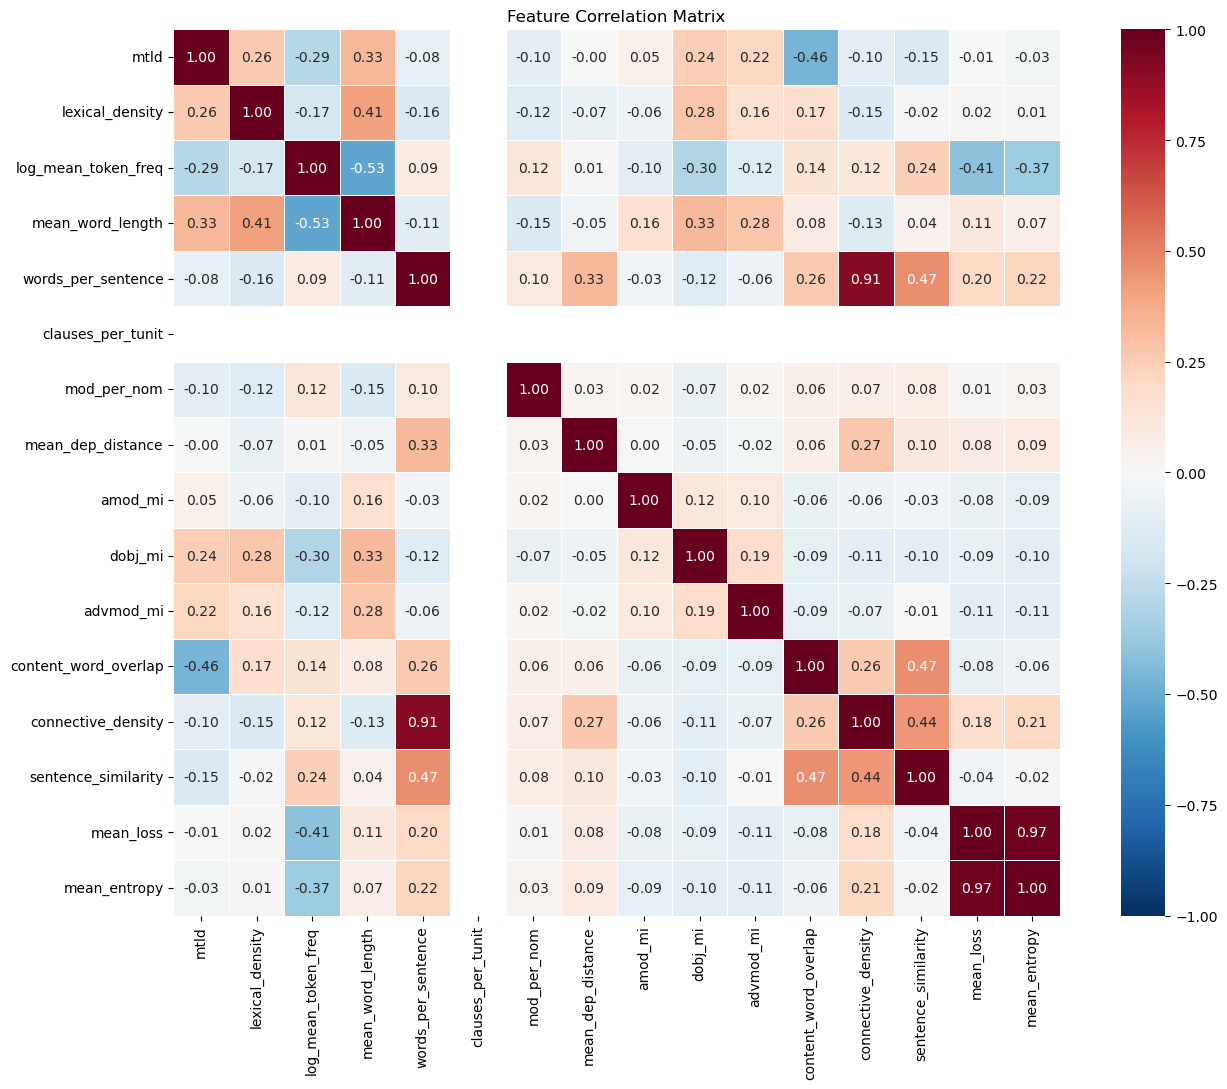

In [10]:
print("\n=== Correlation Heatmap ===")
corr = df_merged[feature_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            square=True, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()